# Demo. Memory Experiment

In [1]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.experiments.memory import MemoryExperiment
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.unrotated import UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock
from src.qec_code.repetition import RepetitionCode, RepetitionCodeExtractionBlock
from src.noise.config import NoiseConfig
from src.ir.qec_system import QECSystem

In [2]:
# Noise parameters and noise model
noise_level = 0.001
noise_params = NoiseConfig(
    p_idle=noise_level,
    p_meas=noise_level,
    p_reset=noise_level,
    p_1q=noise_level,
    p_2q=noise_level
)

### 1. Rotated Surface Code

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...


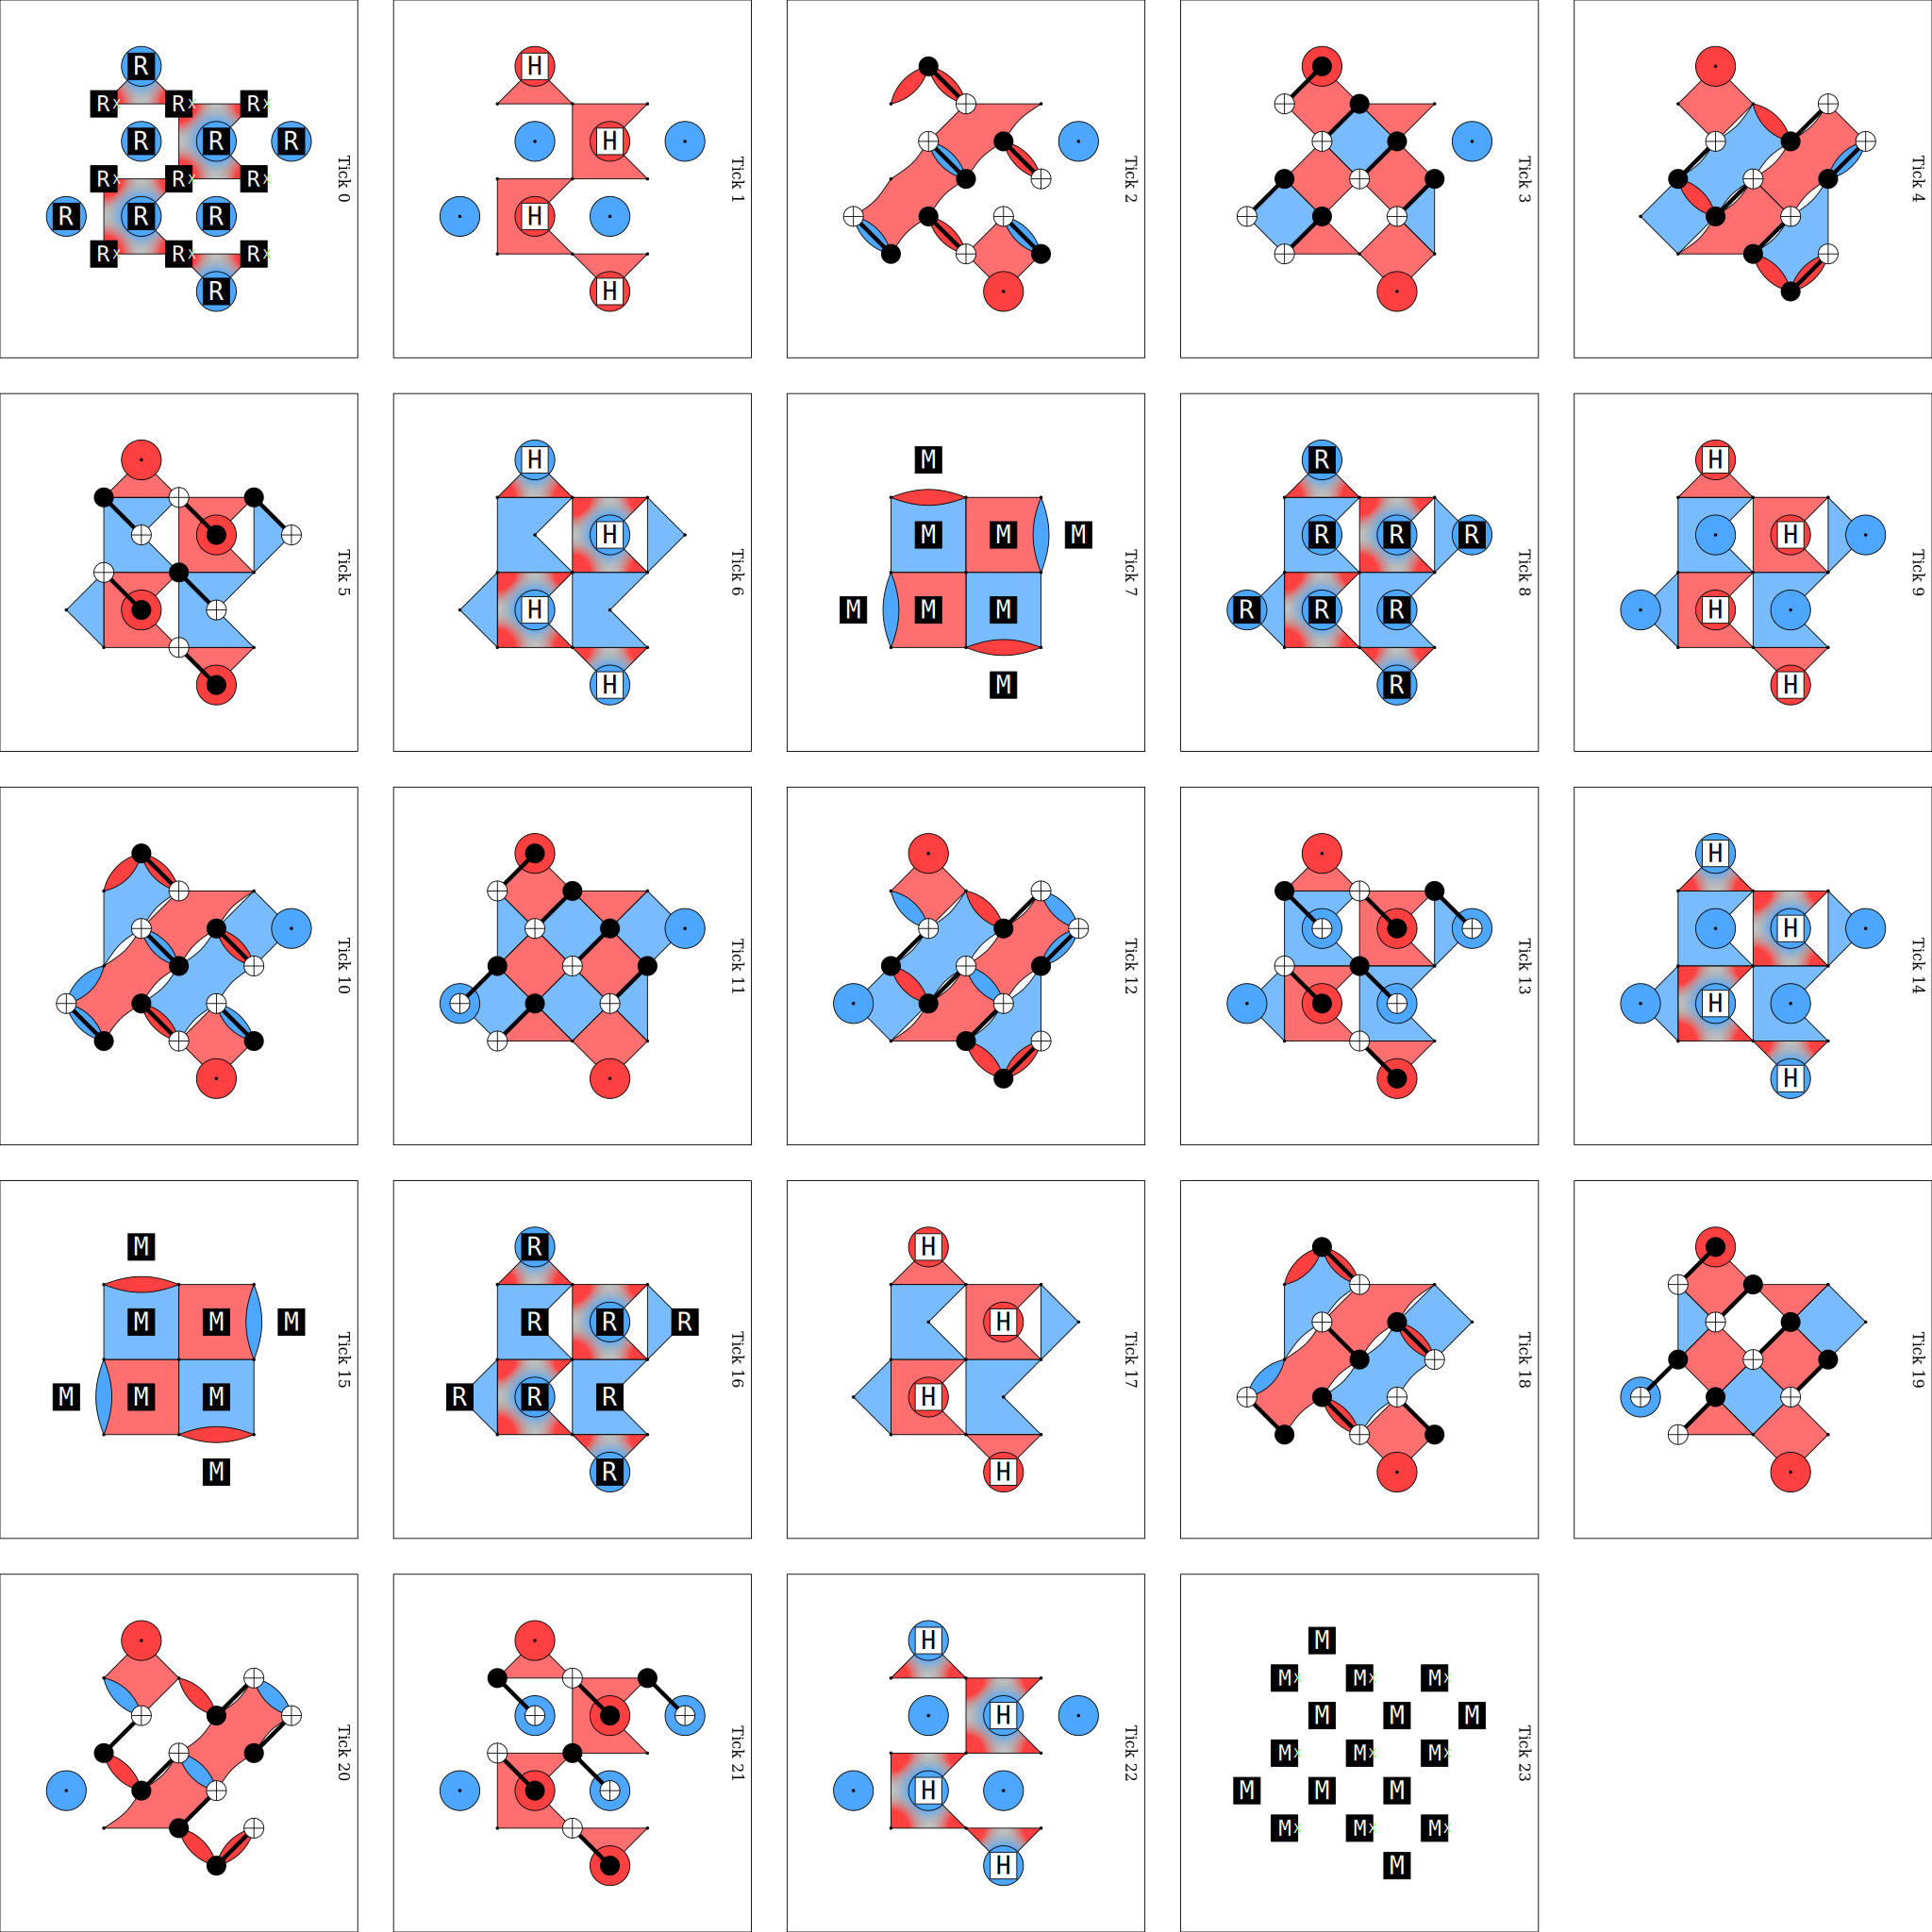

In [3]:
d = 3
surface_code_rotated = RotatedSurfaceCode(distance=d)
# surface_code_rotated.transpose_coords()
# surface_code_rotated.rotate_coords(np.pi/4)
system = QECSystem()
patch = system.add_patch(surface_code_rotated, name="surface_code_rotated")
info = surface_code_rotated.get_info()
mem_exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model='circuit_level',
    basis='X', # "Z" or "X"
    )
mem_circuit_rotated_SF = mem_exp.build()

mem_circuit_rotated_SF.without_noise().diagram("detslice-with-ops-svg")
# mem_circuit_rotated_SF.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0",])


### 2. Unrotated Surface Code

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...


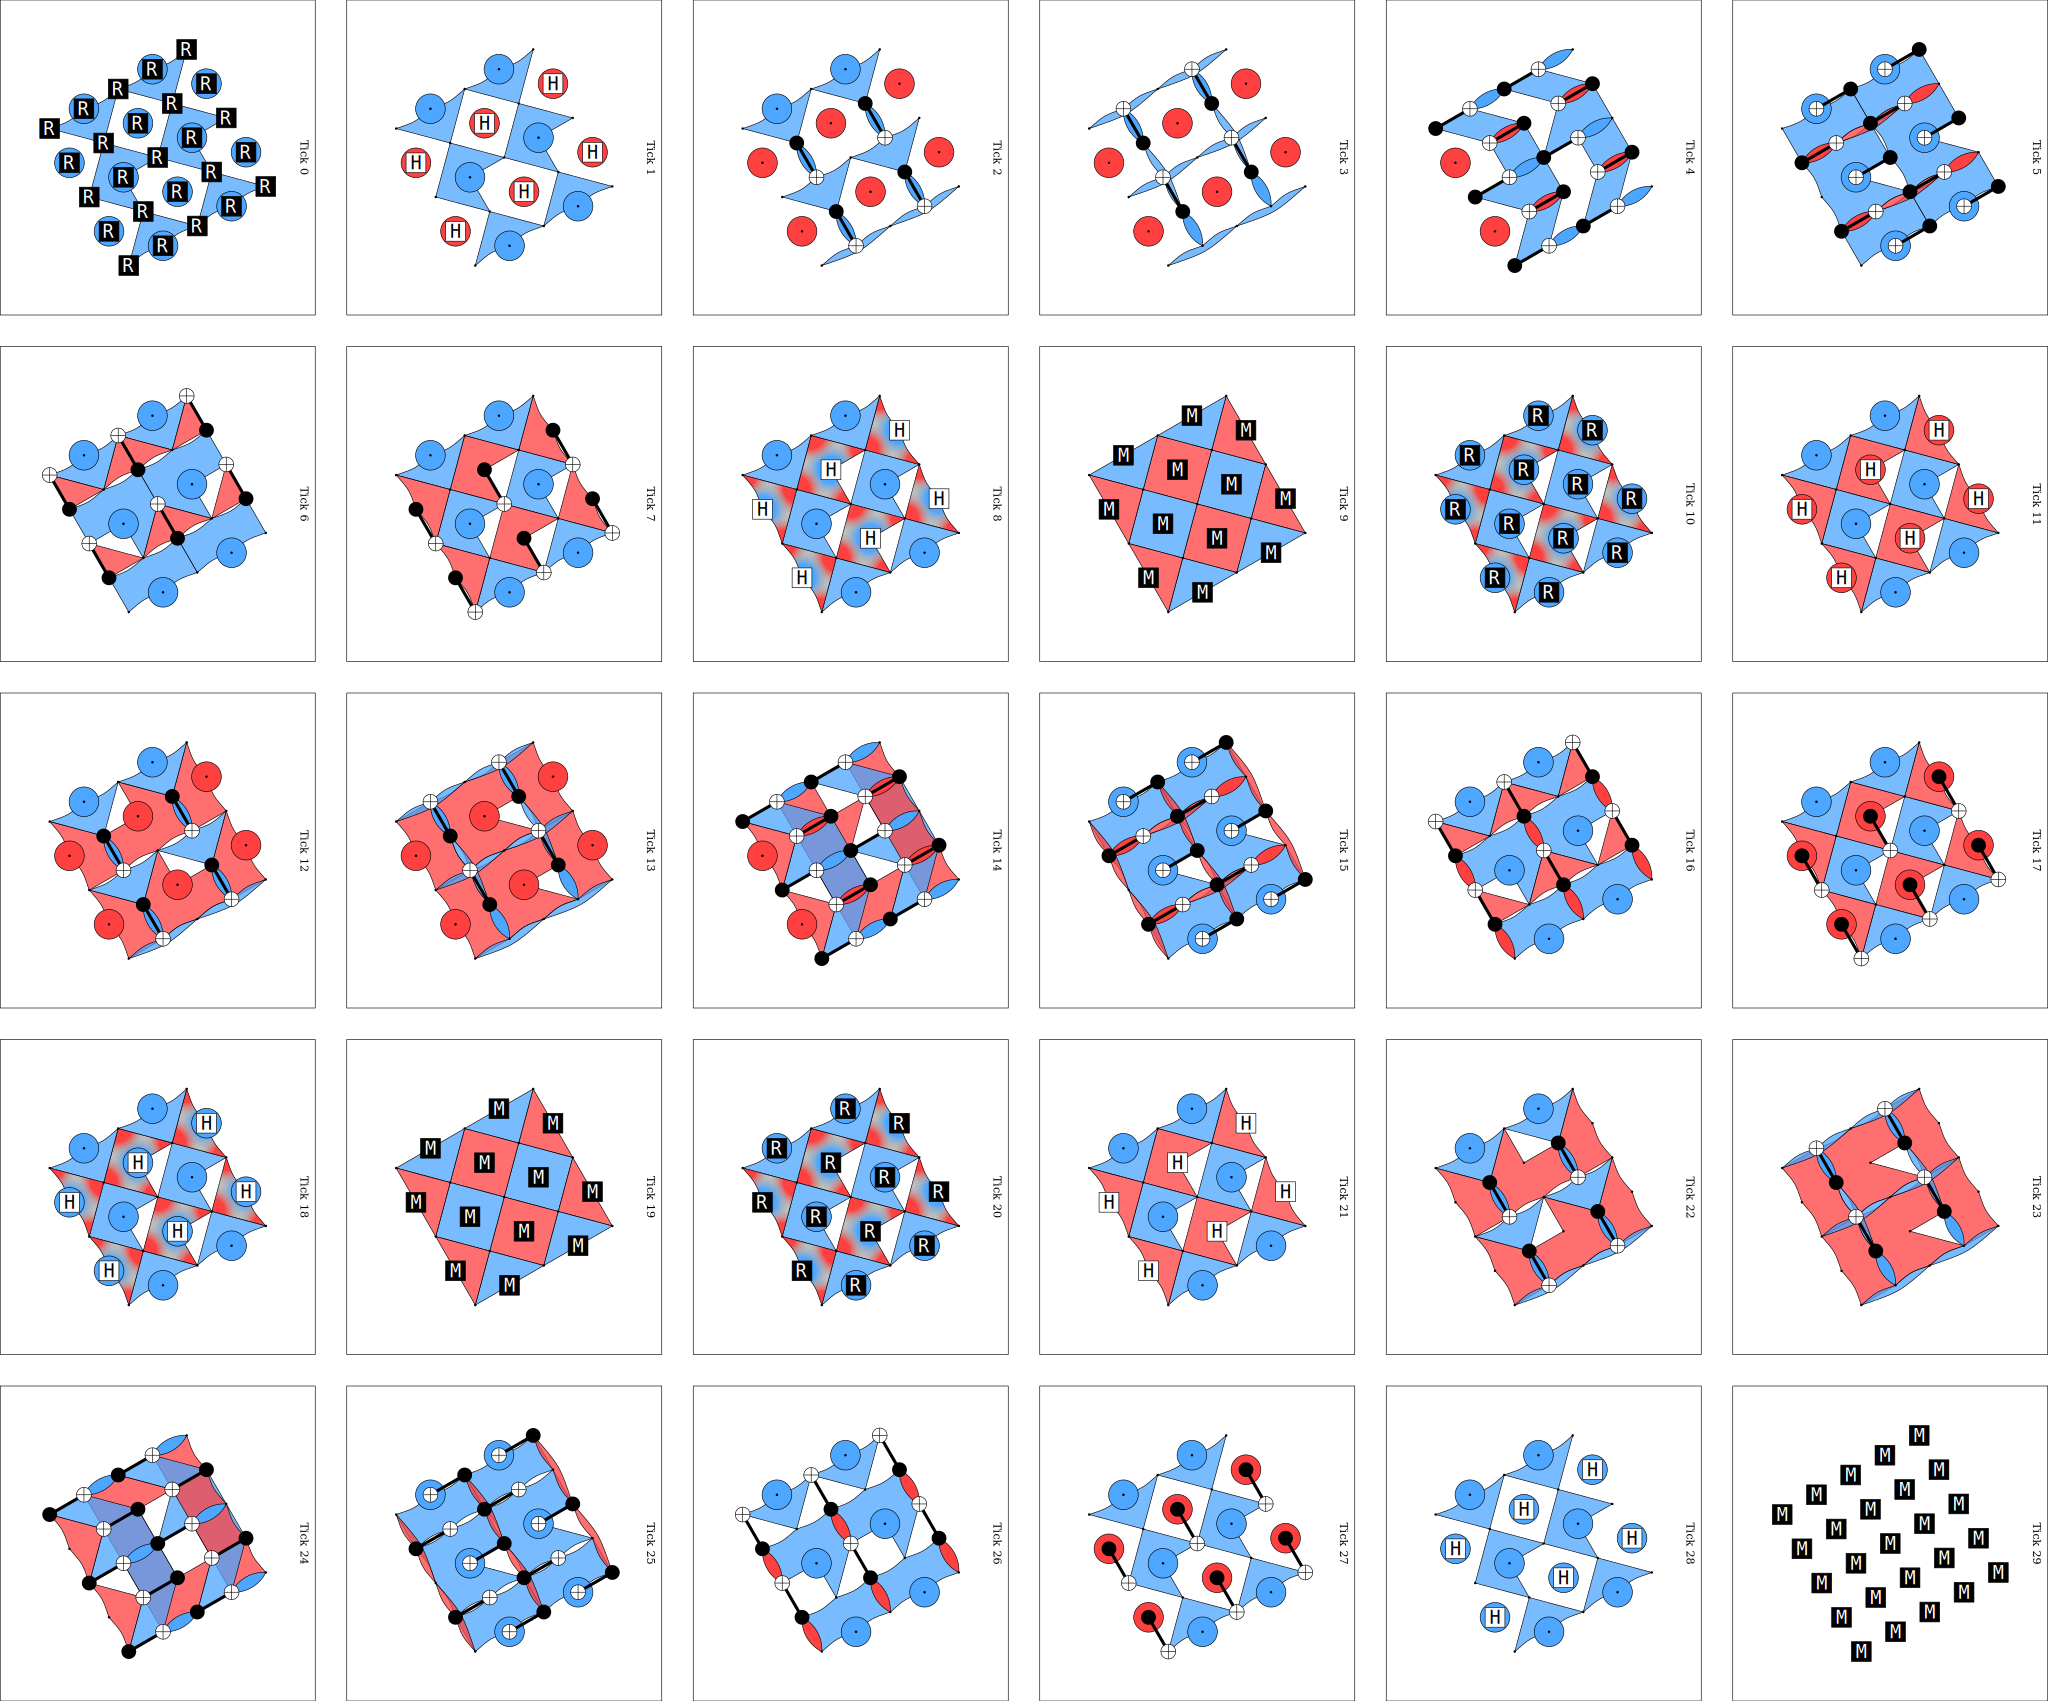

In [4]:
d = 3
surface_code = UnrotatedSurfaceCode(distance=d)
# surface_code.transpose_coords()
surface_code.rotate_coords(np.pi/3)
system = QECSystem()
system.add_patch(surface_code, name="surface_code_unrotated")
mem_exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model='circuit_level',
    basis='Z', # "Z" or "X"
    )
mem_circuit_unrotated_SF = mem_exp.build()
mem_circuit_unrotated_SF.without_noise().diagram("detslice-with-ops-svg")
# mem_circuit_unrotated_SF.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0",])


### 3. Repetition Code

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...


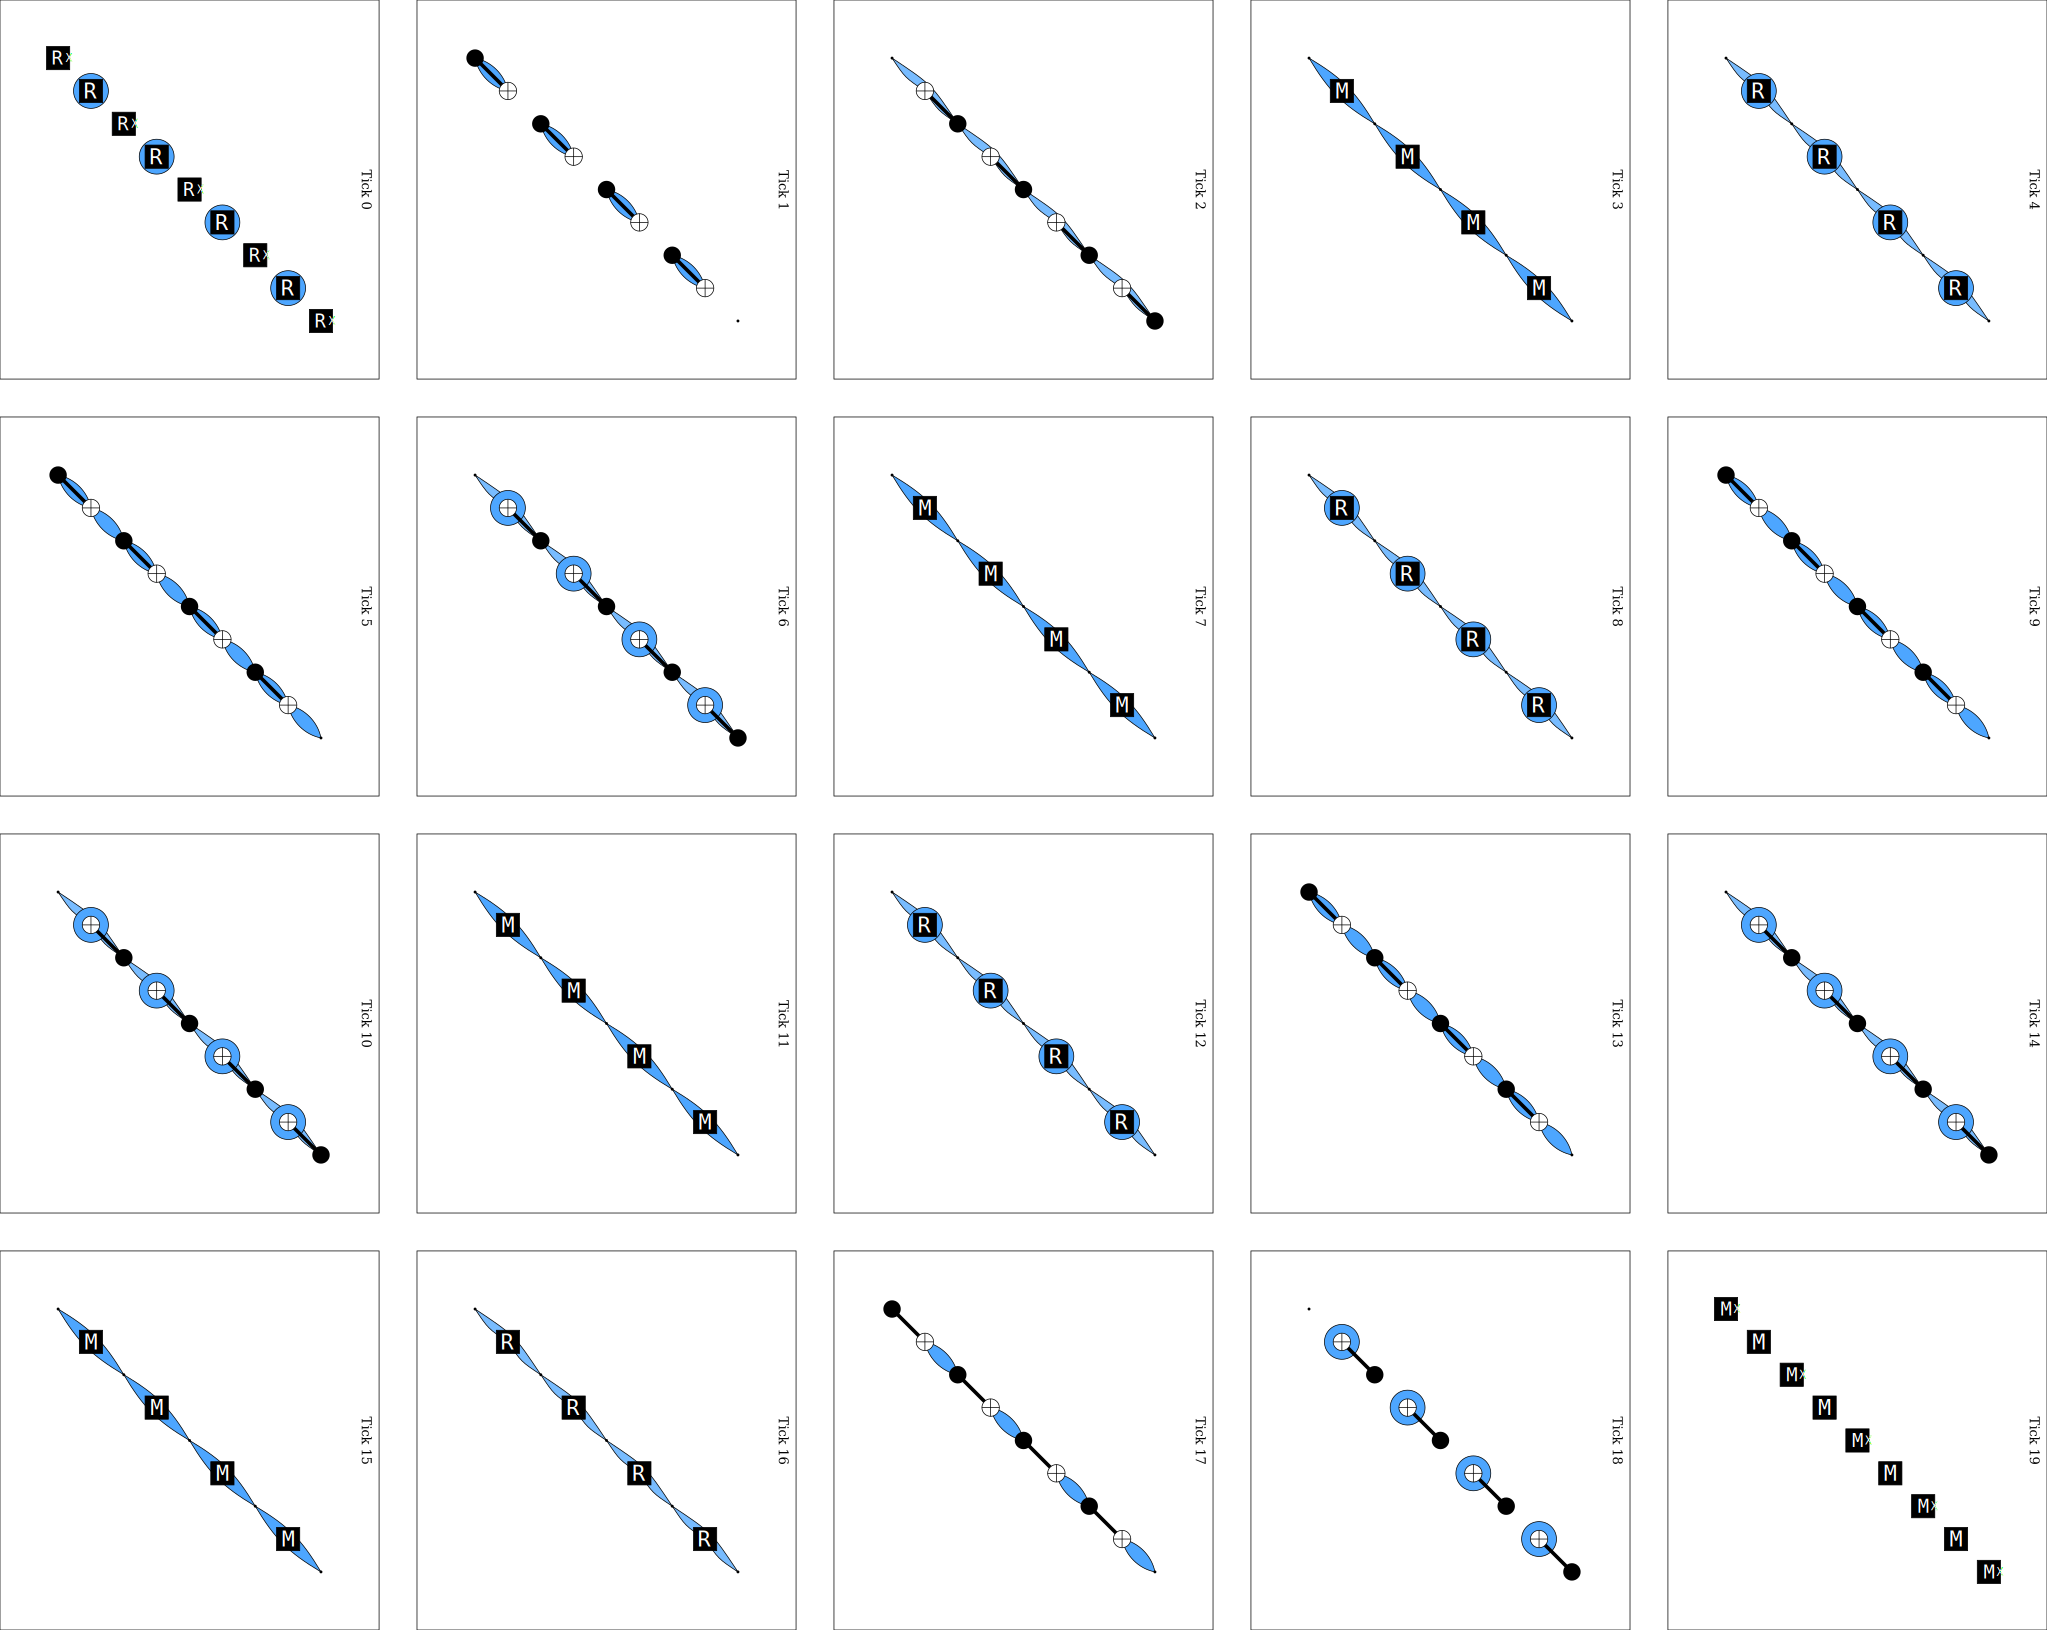

In [5]:
d = 5
repetition_code = RepetitionCode(distance=d)
# repetition_code.get_info()
# repetition_code.transpose_coords()
repetition_code.rotate_coords(theta=np.pi/4)
system = QECSystem()
system.add_patch(repetition_code, name="repetition_code")
mem_exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=RepetitionCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model='circuit_level',
    basis='X', # "Z" or "X"
    )
mem_circuit_rep = mem_exp.build()
mem_circuit_rep.without_noise().diagram("detslice-with-ops-svg")
# mem_circuit_rep.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0",])


### 4. Toric Code

### 6. BB Code

### 5. Color Code